In [1]:
import numpy as np
import scipy as sp

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import mne

import crosspy

import os

from crosspy.routines import mne_injection

## Introduction

In this tutorial, we will show how to run simple but generic pipeline where we compute DFA exponent and two connectivity observables: weighted Phase Lag Index (wPLI) and orthogonalized Correlation Coefficient (oCC).

This tutorial require some open EEG data which can be downloaded from this link below (subject sub-032311, put the data to the data/tutorial_data directory). We will use already preprocessed data to avoid the basic EEG preprocessing such as ICA decomposition or artefact exclustion. 

https://fcon_1000.projects.nitrc.org/indi/retro/MPI_LEMON/downloads/download_EEG.html

In [3]:
data_path_ec = os.path.join('..', 'data', 'tutorial_data', 'sub-032311', 'sub-032311_EC.set')
data_obj_ec = mne.io.read_raw_eeglab(data_path_ec, preload=True, verbose=False)

C:\Users\willy\AppData\Local\Temp\ipykernel_20048\503075848.py:2: RuntimeWarning: Data file name in EEG.data (sub-010017_EC.fdt) is incorrect, the file name must have changed on disk, using the correct file name (sub-032311_EC.fdt).
  data_obj_ec = mne.io.read_raw_eeglab(data_path_ec, preload=True, verbose=False)
C:\Users\willy\AppData\Local\Temp\ipykernel_20048\503075848.py:2: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  data_obj_ec = mne.io.read_raw_eeglab(data_path_ec, preload=True, verbose=False)
C:\Users\willy\AppData\Local\Temp\ipykernel_20048\503075848.py:2: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  data_obj_ec = mne.io.read_raw_eeglab(data_path_ec, preload=True, verbose=False)


Since EEG data is prune to volume conduction and leakage, applying surface laplacian should improve the observables quality and connectivity in particular. For more details about it I recommend a videom from amazing Mike X Cohen

https://www.youtube.com/watch?v=6njzcZWuh9Q

In [143]:
data_obj_ec.set_eeg_reference(projection=True, verbose=False).apply_proj(verbose=False)
data_obj_ec_csd = mne.preprocessing.compute_current_source_density(data_obj_ec, verbose=False)

data_broadband = data_obj_ec_csd.get_data()

C:\Users\willy\AppData\Local\Temp\ipykernel_20048\3204036943.py:1: RuntimeWarning: An average reference projection was already added. The data has been left untouched.
  data_obj_ec.set_eeg_reference(projection=True, verbose=False).apply_proj(verbose=False)


At the most basic level, computing observables require:

1. Narrow-band filter data (in CrossPy the Complex Wavelet Transform with Morlet wavelets is the default way of filtering the data)
2. Pass the data to a corresponding function (e.g. compute_dfa)

As easy as it seems!

Lets compute our observables of intereste for a range of equally log-spaced frequencies from 1 to 50Hz. Since Morlet wavelets have exponential scaling in spectral domain, wavelets for higher frequencies will have wider span in comparison to lower frequencies, thus linear spacing would make lower frequencies (e.g. theta/delta) undersampled but higher frequencies will be oversampled.

In [ ]:
frequencies_of_interest = np.geomspace(1, 50, 30)

n_chans, n_ts = data_broadband.shape

dfa_as_frequency = np.zeros((len(frequencies_of_interest), n_chans))
bis_as_frequency = np.zeros((len(frequencies_of_interest), n_chans))
wpli_as_frequency = np.zeros((len(frequencies_of_interest), n_chans, n_chans))
occ_as_frequency = np.zeros((len(frequencies_of_interest), n_chans, n_chans))

for frequency_idx, frequency in enumerate(frequencies_of_interest):
    # for DFA we need to specify window sizes, typycally we recommend the smallest window to start at ~10 cycles of narrow-band central frequency
    # and larger windows to be roughly 25% of signal length to have enough data for robust mean estimation.
    samples_per_cycle = data_obj_ec.info['sfreq']/frequency
    dfa_window_size_for_frequency = np.geomspace(10*samples_per_cycle, n_ts//4)

    # we pass n_jobs='cuda' to enforce filtering on GPU to make it faster and avoid copying data from CPU to GPU back and forth.
    data_filt = crosspy.preprocessing.signal.filter_data(data_broadband, sfreq=data_obj_ec.info['sfreq'], frequency=frequency, omega=5.0, n_jobs='cuda')
    data_envelope = np.abs(data_filt)

    # DFA is computed using envelope of a narrow-band signal while oCC and wPLI require complex data.
    # note:  observables functions utilize CPU/GPU based on type of the data. e.g. if your signal is stored on CPU, the observables will be computed using it.
    # since we filtered the data using GPU and our data is stored on it, the functions will automatically use it too.
    dfa_res = crosspy.observables.criticality.lrtc.compute_dfa(data_envelope, dfa_window_size_for_frequency)
    bis_res = crosspy.observables.criticality.bistability.compute_BiS(data_envelope, method='em')
    wpli_res = crosspy.observables.connectivity.synchrony.compute_wpli(data_filt, debias=False)
    occ_res = crosspy.observables.connectivity.amplitude_correlations.compute_occ(data_filt)
    
    # since we use GPU to compute our observables, wPLI and oCC functions return GPU arrays and we need to get them back to CPU.
    # note: DFA uses statsmodels to fit a robust linear regression, thus it always returns CPU data.
    dfa_as_frequency[frequency_idx] = dfa_res.dfa_values
    wpli_as_frequency[frequency_idx] = np.abs(wpli_res.get())
    occ_as_frequency[frequency_idx] = np.abs(occ_res.get())
    bis_as_frequency[frequency_idx] = bis_res.get()

The same could be achived by calling .compute_dfa or .compute_connectivity functions of MNE objects.

Note : in order to add those injections, one needs to import crosspy.routines.mne_injection

In [134]:
dfa_as_frequency_mne = data_obj_ec_csd.compute_dfa(frequencies=frequencies_of_interest, min_window_size=5, max_window_size=0.25, omega=5.0, force_gpu=True)
wpli_as_frequency_mne = data_obj_ec_csd.compute_connectivity(method='wpli', frequencies=frequencies_of_interest, omega=5.0, force_gpu=True)
occ_as_frequency_mne = data_obj_ec_csd.compute_connectivity(method='occ', frequencies=frequencies_of_interest,omega=5.0, force_gpu=True)

Lets plot an average observables for each frequency.

We can see a clear peak for all observables at alpha (~10Hz) frequency.

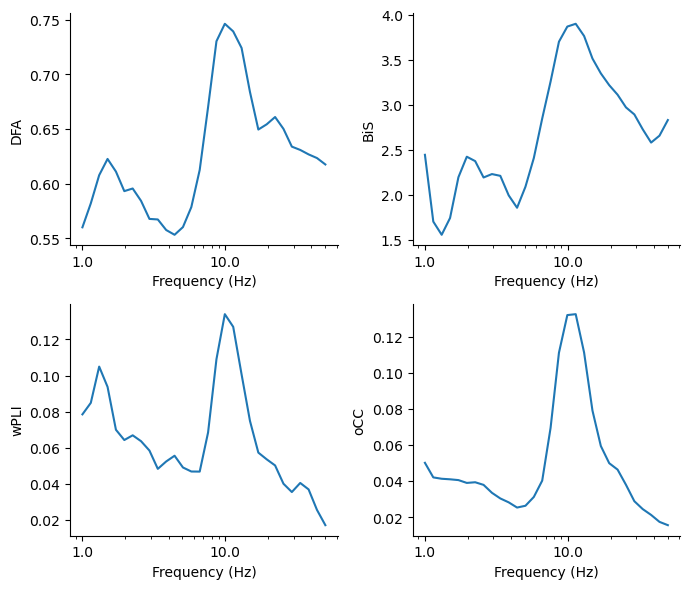

In [138]:
fig, axes = plt.subplots(figsize=(7,6), ncols=2, nrows=2)

for ax, arr, title in zip(axes.flatten(), [dfa_as_frequency, bis_as_frequency, wpli_as_frequency, occ_as_frequency], ['DFA', 'BiS', 'wPLI', 'oCC']):
    arr_agg = arr.reshape(arr.shape[0], -1).mean(axis=-1)
    ax.semilogx(frequencies_of_interest, arr_agg)

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel(title)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

fig.tight_layout()

We can also visualize our observables for each frequency: topoplot for univariate DFA (we have one value per electrode) or as 2D map for connectivity metrices.

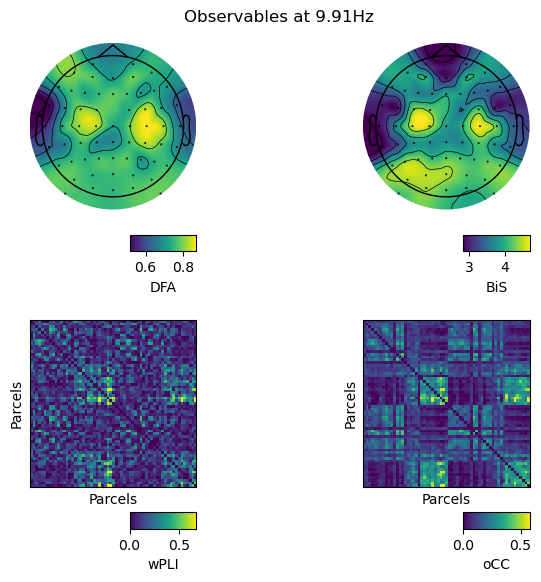

In [142]:
fig, axes = plt.subplots(figsize=(7,6), ncols=2, nrows=2)

for ax, arr, title in zip(axes[0], [dfa_as_frequency[17], bis_as_frequency[17]], ['DFA', 'BiS']):
    arr_vlim = (arr.min(), arr.max())
    imh, _ = mne.viz.plot_topomap(arr, data_obj_ec.info, axes=ax, show=False, cmap='viridis', vlim=arr_vlim)

    cax = ax.inset_axes([0.6, -0.25, 0.4, 0.1])
    fig.colorbar(imh, cax=cax, orientation='horizontal')
    cax.set_xlabel(title)

for ax, arr, title in zip(axes[1], [wpli_as_frequency, occ_as_frequency], ['wPLI', 'oCC']):
    imh = ax.imshow(arr[17], interpolation='none')
    cax = ax.inset_axes([0.6, -0.25, 0.4, 0.1])
    fig.colorbar(imh, cax=cax, orientation='horizontal')

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel('Parcels')
    ax.set_ylabel('Parcels')

    cax.set_xlabel(title)

fig.suptitle(f'Observables at {round(frequencies_of_interest[17], 2)}Hz')
fig.tight_layout()

## Significance test

After computing the observables, it is natural to ask whether they are statistically significant. The null distribution of an observable depends on many analysis choices (for example, filtering parameters, window length, and the method used to estimate phases or envelopes). For this reason, analytical confidence intervals are often unavailable or unreliable, and surrogate-data methods provide a practical way to estimate a null distribution and compute p-values.

The key idea is that the surrogate should destroy the specific structure we want to test, while preserving other relevant properties of the data. For example, for DFA we typically want a null model that preserves the original signal's power spectrum (and, ideally, its amplitude distribution), while removing additional temporal structure beyond what is implied by those constraints. Simple time shuffling or spectral shuffling is therefore not appropriate. A common choice is the iterative amplitude-adjusted Fourier transform (IAAFT), which generates surrogates with (approximately) the same power spectrum and the same marginal amplitude distribution as the original data.

For connectivity measures - especially phase-based measures such as wPLI—the hypothesis is essentially: how stable are the phase relationships between two signals over time? A convenient surrogate approach is circular time shifting (rotation): we randomly shift one (or all) channels in time to destroy pairwise alignment between channels while preserving each channel’s internal structure (e.g., autocorrelation and power spectrum). We then recompute the connectivity measure on the surrogates to obtain a null distribution.

Note: The following block can be time-consuming, because generating surrogates (and recomputing observables on them) may take a while.

In [ ]:
from crosspy.utils.surrogates import _create_iaaft_surrogates, _create_time_shift_surrogates
import cupy as cp

import tqdm.notebook as tqdm

In [ ]:
n_surr = 100
data_orig_gpu = cp.array(data_broadband)

dfa_surr_values_as_freq = np.zeros((n_surr, len(frequencies_of_interest), n_chans))

for i in tqdm.trange(n_surr):
    data_surr_bb = _create_iaaft_surrogates(data_orig_gpu)

    for freq_idx, frequency in enumerate(frequencies_of_interest):
        samples_per_cycle = data_obj_ec.info['sfreq']/frequency
        dfa_window_size_for_frequency = np.geomspace(10*samples_per_cycle, n_ts//4)

        data_filt = crosspy.preprocessing.signal.filter_data(data_surr_bb, sfreq=data_obj_ec.info['sfreq'], frequency=frequency, omega=5.0, n_jobs='cuda')
        data_envelope = np.abs(data_filt)

        dfa_surr_values_as_freq[i, freq_idx] = crosspy.observables.criticality.lrtc.compute_dfa(data_envelope, dfa_window_size_for_frequency).dfa_values

dfa_pvalues = (dfa_as_frequency[None] <= dfa_surr_values_as_freq).mean(axis=0)
dfa_zs = (dfa_as_frequency - dfa_surr_values_as_freq.mean(axis=0))/dfa_surr_values_as_freq.std(axis=0)

  0%|          | 0/100 [00:00<?, ?it/s]

In [147]:
wpli_surr_values_as_freq = np.zeros((n_surr, len(frequencies_of_interest), n_chans, n_chans))
occ_surr_values_as_freq = np.zeros((n_surr, len(frequencies_of_interest), n_chans, n_chans))

for i in tqdm.trange(n_surr):
    data_surr_bb = _create_time_shift_surrogates(data_orig_gpu)

    for freq_idx, frequency in enumerate(frequencies_of_interest):
        data_filt = crosspy.preprocessing.signal.filter_data(data_surr_bb, sfreq=data_obj_ec.info['sfreq'], frequency=frequency, omega=5.0, n_jobs='cuda')

        wpli_surr_values_as_freq[i, freq_idx] = np.abs(crosspy.observables.connectivity.synchrony.compute_wpli(data_filt, debias=False).get())
        occ_surr_values_as_freq[i, freq_idx] = np.abs(crosspy.observables.connectivity.amplitude_correlations.compute_occ(data_filt).get())

  0%|          | 0/100 [00:00<?, ?it/s]

In [152]:
wpli_pvalues = (wpli_as_frequency[None] <= wpli_surr_values_as_freq).mean(axis=0)
occ_pvalues = (occ_as_frequency[None] <= occ_surr_values_as_freq).mean(axis=0)

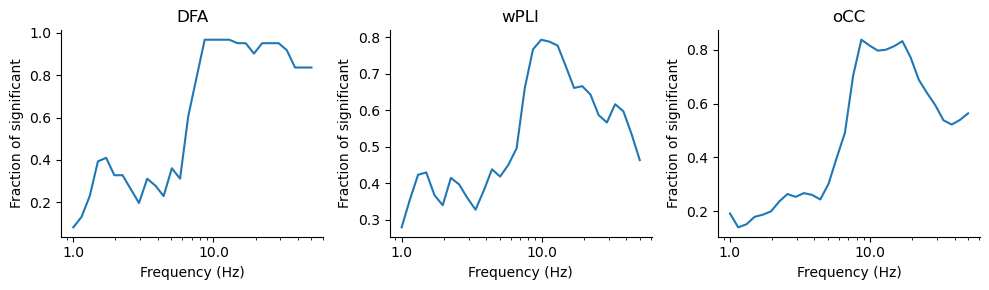

In [160]:
fig, axes = plt.subplots(figsize=(10,3), ncols=3)

for ax, arr, title in zip(axes.flatten(), [dfa_pvalues, wpli_pvalues,  occ_pvalues], ['DFA', 'wPLI', 'oCC']):
    arr_agg = (arr.reshape(arr.shape[0], -1) <= 1e-1).mean(axis=-1)
    ax.semilogx(frequencies_of_interest, arr_agg)

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Fraction of significant')
    ax.set_title(title)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

fig.tight_layout()